In [ ]:
!pip install imblearn seaborn xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time as tm
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 140)
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: C:\Users\gerem\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [72]:
df_flights = pd.read_csv(r"C:\Users\gerem\Desktop\Tech_challenge_3_M_Supervisionados_N_Supervisionados\data\flights.csv")

In [73]:
condicoes = [
    df_flights['ARRIVAL_DELAY'] > 0,
    df_flights['ARRIVAL_DELAY'] <= 0
]

valores = ['atrasado', 'pontual']

df_flights['status_voo'] = np.select(condicoes, valores, default='pontual')


In [75]:
df_flights[
    df_flights['DESTINATION_AIRPORT'].map(lambda x: isinstance(x, int))
]['DESTINATION_AIRPORT'].sort_values(ascending = False).unique()

array([16218, 15991, 15919, 15841, 15624, 15607, 15497, 15412, 15411,
       15401, 15389, 15380, 15376, 15370, 15356, 15323, 15304, 15295,
       15249, 15096, 15070, 15048, 15041, 15027, 15024, 15016, 14986,
       14960, 14952, 14908, 14905, 14893, 14869, 14843, 14842, 14831,
       14828, 14814, 14794, 14783, 14771, 14747, 14730, 14711, 14709,
       14698, 14696, 14689, 14685, 14683, 14679, 14674, 14635, 14633,
       14588, 14576, 14574, 14570, 14543, 14524, 14520, 14492, 14489,
       14487, 14457, 14321, 14307, 14262, 14256, 14254, 14252, 14222,
       14193, 14150, 14122, 14113, 14109, 14108, 14107, 14100, 14098,
       14057, 14027, 14025, 14006, 13970, 13964, 13933, 13931, 13930,
       13891, 13873, 13871, 13851, 13830, 13796, 13795, 13577, 13541,
       13502, 13495, 13487, 13486, 13485, 13476, 13459, 13433, 13422,
       13377, 13367, 13360, 13344, 13342, 13303, 13296, 13290, 13277,
       13264, 13256, 13244, 13241, 13232, 13230, 13204, 13198, 13184,
       13158, 13127,

In [76]:
df_flights['DESTINATION_AIRPORT'].map(type).value_counts()



DESTINATION_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [77]:
df_flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'status_voo'],
      dtype='object')

In [78]:

(df_flights.isna().sum() / df_flights.shape[0] * 100).sort_values(ascending = False)

CANCELLATION_REASON    98.455357
SECURITY_DELAY         81.724960
WEATHER_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
AIRLINE_DELAY          81.724960
AIR_SYSTEM_DELAY       81.724960
ELAPSED_TIME            1.805629
AIR_TIME                1.805629
ARRIVAL_DELAY           1.805629
ARRIVAL_TIME            1.589822
TAXI_IN                 1.589822
WHEELS_ON               1.589822
WHEELS_OFF              1.530259
TAXI_OUT                1.530259
DEPARTURE_TIME          1.480526
DEPARTURE_DELAY         1.480526
TAIL_NUMBER             0.252978
SCHEDULED_TIME          0.000103
SCHEDULED_DEPARTURE     0.000000
MONTH                   0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
ORIGIN_AIRPORT          0.000000
YEAR                    0.000000
DESTINATION_AIRPORT     0.000000
DAY                     0.000000
DISTANCE                0.000000
DIVERTED                0.000000
SCHEDULED_ARRIVAL       0.000000
CANCELLED 

In [79]:
df_flights.shape


(5819079, 32)

In [80]:
df_flights = df_flights.drop(columns=['CANCELLATION_REASON', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY'])

In [81]:
cols_num = [
    'ELAPSED_TIME','AIR_TIME', 'ARRIVAL_DELAY',
    'TAXI_IN', 'TAXI_OUT',
    'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'WHEELS_ON', 'WHEELS_OFF', 'DEPARTURE_TIME','ARRIVAL_TIME'
]

df_flights[cols_num] = df_flights[cols_num].apply(
    lambda col: col.fillna(col.median())
)


In [82]:
df_flights.shape

(5819079, 26)

In [83]:
colunas_traduzidas = {
    'YEAR': 'ano',
    'MONTH': 'mes',
    'DAY': 'dia',
    'DAY_OF_WEEK': 'dia_da_semana',
    'AIRLINE': 'companhia_aerea',
    'FLIGHT_NUMBER': 'numero_voo',
    'TAIL_NUMBER': 'matricula_aeronave',
    'ORIGIN_AIRPORT': 'aeroporto_origem',
    'DESTINATION_AIRPORT': 'aeroporto_destino',
    'SCHEDULED_DEPARTURE': 'partida_programada',
    'DEPARTURE_TIME': 'horario_partida_real',
    'DEPARTURE_DELAY': 'atraso_partida',
    'TAXI_OUT': 'tempo_taxi_saida',
    'WHEELS_OFF': 'decolagem_real',
    'SCHEDULED_TIME': 'tempo_programado_voo',
    'ELAPSED_TIME': 'tempo_total_voo',
    'AIR_TIME': 'tempo_no_ar',
    'DISTANCE': 'distancia',
    'WHEELS_ON': 'pouso_real',
    'TAXI_IN': 'tempo_taxi_chegada',
    'SCHEDULED_ARRIVAL': 'chegada_programada',
    'ARRIVAL_TIME': 'horario_chegada_real',
    'ARRIVAL_DELAY': 'atraso_chegada',
    'DIVERTED': 'voo_desviado',
    'CANCELLED': 'voo_cancelado'
}


In [84]:
df_flights = df_flights.rename(columns=colunas_traduzidas)

In [85]:
df_flights.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ano,5819079.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
mes,5819079.0,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
dia,5819079.0,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
dia_da_semana,5819079.0,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
numero_voo,5819079.0,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
partida_programada,5819079.0,1329.602470,483.751821,1.0,917.0,1325.0,1730.0,2359.0
horario_partida_real,5819079.0,1335.127386,492.735118,1.0,925.0,1330.0,1736.0,2400.0
atraso_partida,5819079.0,9.201820,36.831030,-82.0,-5.0,-2.0,7.0,1988.0
tempo_taxi_saida,5819079.0,16.039960,8.830911,1.0,11.0,14.0,19.0,225.0
decolagem_real,5819079.0,1356.953991,494.187310,1.0,939.0,1343.0,1750.0,2400.0


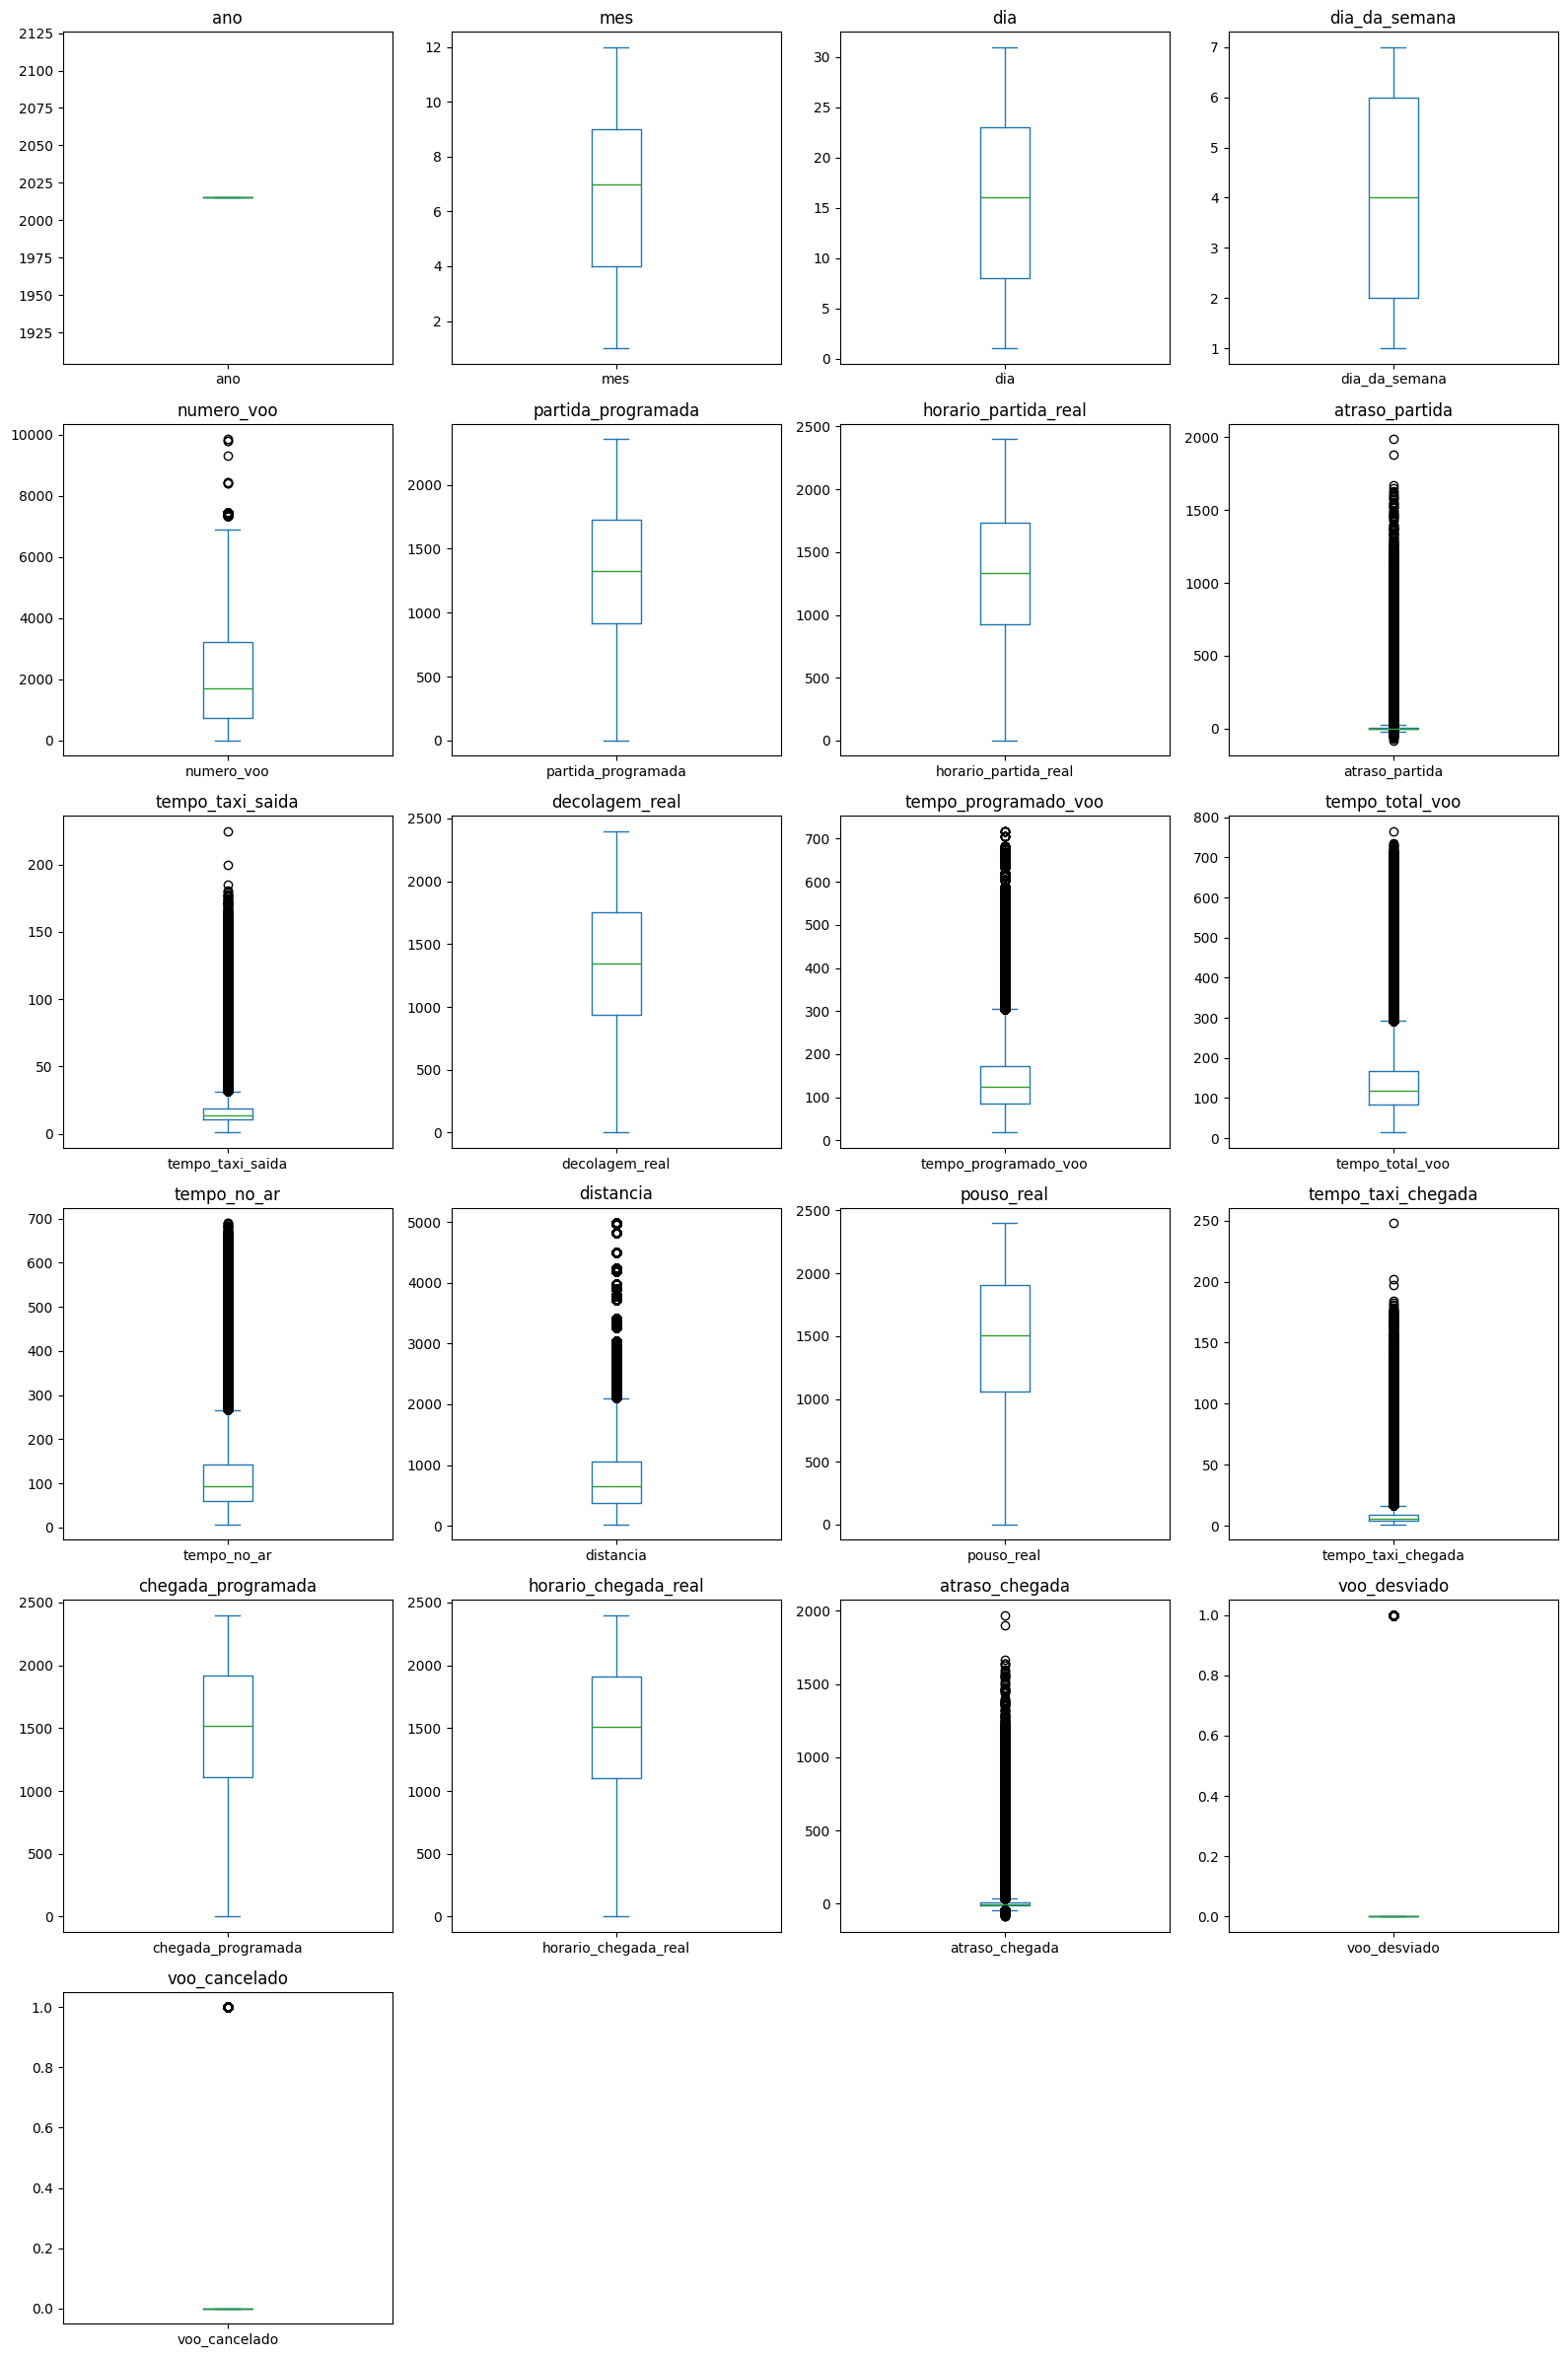

In [86]:


cols = df_flights.select_dtypes(include='number').columns

ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    df_flights[col].plot(kind='box', ax=ax)
    ax.set_title(col)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


In [ ]:
df_flights['tempo_taxi_saida_faixa'] = pd.cut(
    df_flights['tempo_taxi_saida'],
    bins=[0, 45, 100, 150, 180, 200],
    labels=[0,1,2,3,4]
).astype(float)

df_flights['tempo_programado_voo_faixa'] = pd.cut(
    df_flights['tempo_programado_voo'],
    bins=[0,300, 400, 500, 600, 700],
    labels=[0,1,2,3,4]
).astype(float)

df_flights['tempo_total_voo_faixa'] = pd.cut(
    df_flights['tempo_total_voo'],
    bins=[0,300, 400, 500, 600, 700],
    labels=[0,1,2,3,4]
).astype(float)

df_flights['tempo_no_ar_faixa'] = pd.cut(
    df_flights['tempo_no_ar'],
    bins=[0,280, 400, 500, 600, 680],
    labels=[0,1,2,3,4]
).astype(float)

df_flights['distancia_faixa'] = pd.cut(
    df_flights['distancia'],
    bins=[0,2100, 3000, 3500, 4000, 5000],
    labels=[0,1,2,3,4]
).astype(float)



In [88]:
df_flights.dtypes

ano                             int64
mes                             int64
dia                             int64
dia_da_semana                   int64
companhia_aerea                object
numero_voo                      int64
matricula_aeronave             object
aeroporto_origem               object
aeroporto_destino              object
partida_programada              int64
horario_partida_real          float64
atraso_partida                float64
tempo_taxi_saida              float64
decolagem_real                float64
tempo_programado_voo          float64
tempo_total_voo               float64
tempo_no_ar                   float64
distancia                       int64
pouso_real                    float64
tempo_taxi_chegada            float64
chegada_programada              int64
horario_chegada_real          float64
atraso_chegada                float64
voo_desviado                    int64
voo_cancelado                   int64
status_voo                     object
tempo_taxi_s

In [89]:
df_flights.head()

,ano,mes,dia,dia_da_semana,companhia_aerea,numero_voo,matricula_aeronave,aeroporto_origem,aeroporto_destino,partida_programada,horario_partida_real,atraso_partida,tempo_taxi_saida,decolagem_real,tempo_programado_voo,tempo_total_voo,tempo_no_ar,distancia,pouso_real,tempo_taxi_chegada,chegada_programada,horario_chegada_real,atraso_chegada,voo_desviado,voo_cancelado,status_voo,tempo_taxi_saida_faixa,tempo_programado_voo_faixa,tempo_total_voo_faixa,tempo_no_ar_faixa,distancia_faixa,tempo_taxi_chegada_faixa
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,pontual,0.0,0.0,0.0,0.0,1.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,atrasado,0.0,0.0,0.0,0.0,1.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,pontual,0.0,0.0,0.0,0.0,1.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0


In [90]:
#df_flights['atraso_partida'] = np.log1p(df_flights['atraso_partida'])
df_flights['tempo_taxi_saida'] = np.log1p(df_flights['tempo_taxi_saida'])
df_flights['tempo_programado_voo'] = np.log1p(df_flights['tempo_programado_voo'])
df_flights['tempo_total_voo'] = np.log1p(df_flights['tempo_total_voo'])
df_flights['tempo_no_ar'] = np.log1p(df_flights['tempo_no_ar'])
df_flights['distancia'] = np.log1p(df_flights['distancia'])
df_flights['tempo_taxi_chegada'] = np.log1p(df_flights['tempo_taxi_chegada'])
#df_flights['atraso_chegada'] = np.log1p(df_flights['atraso_chegada'])

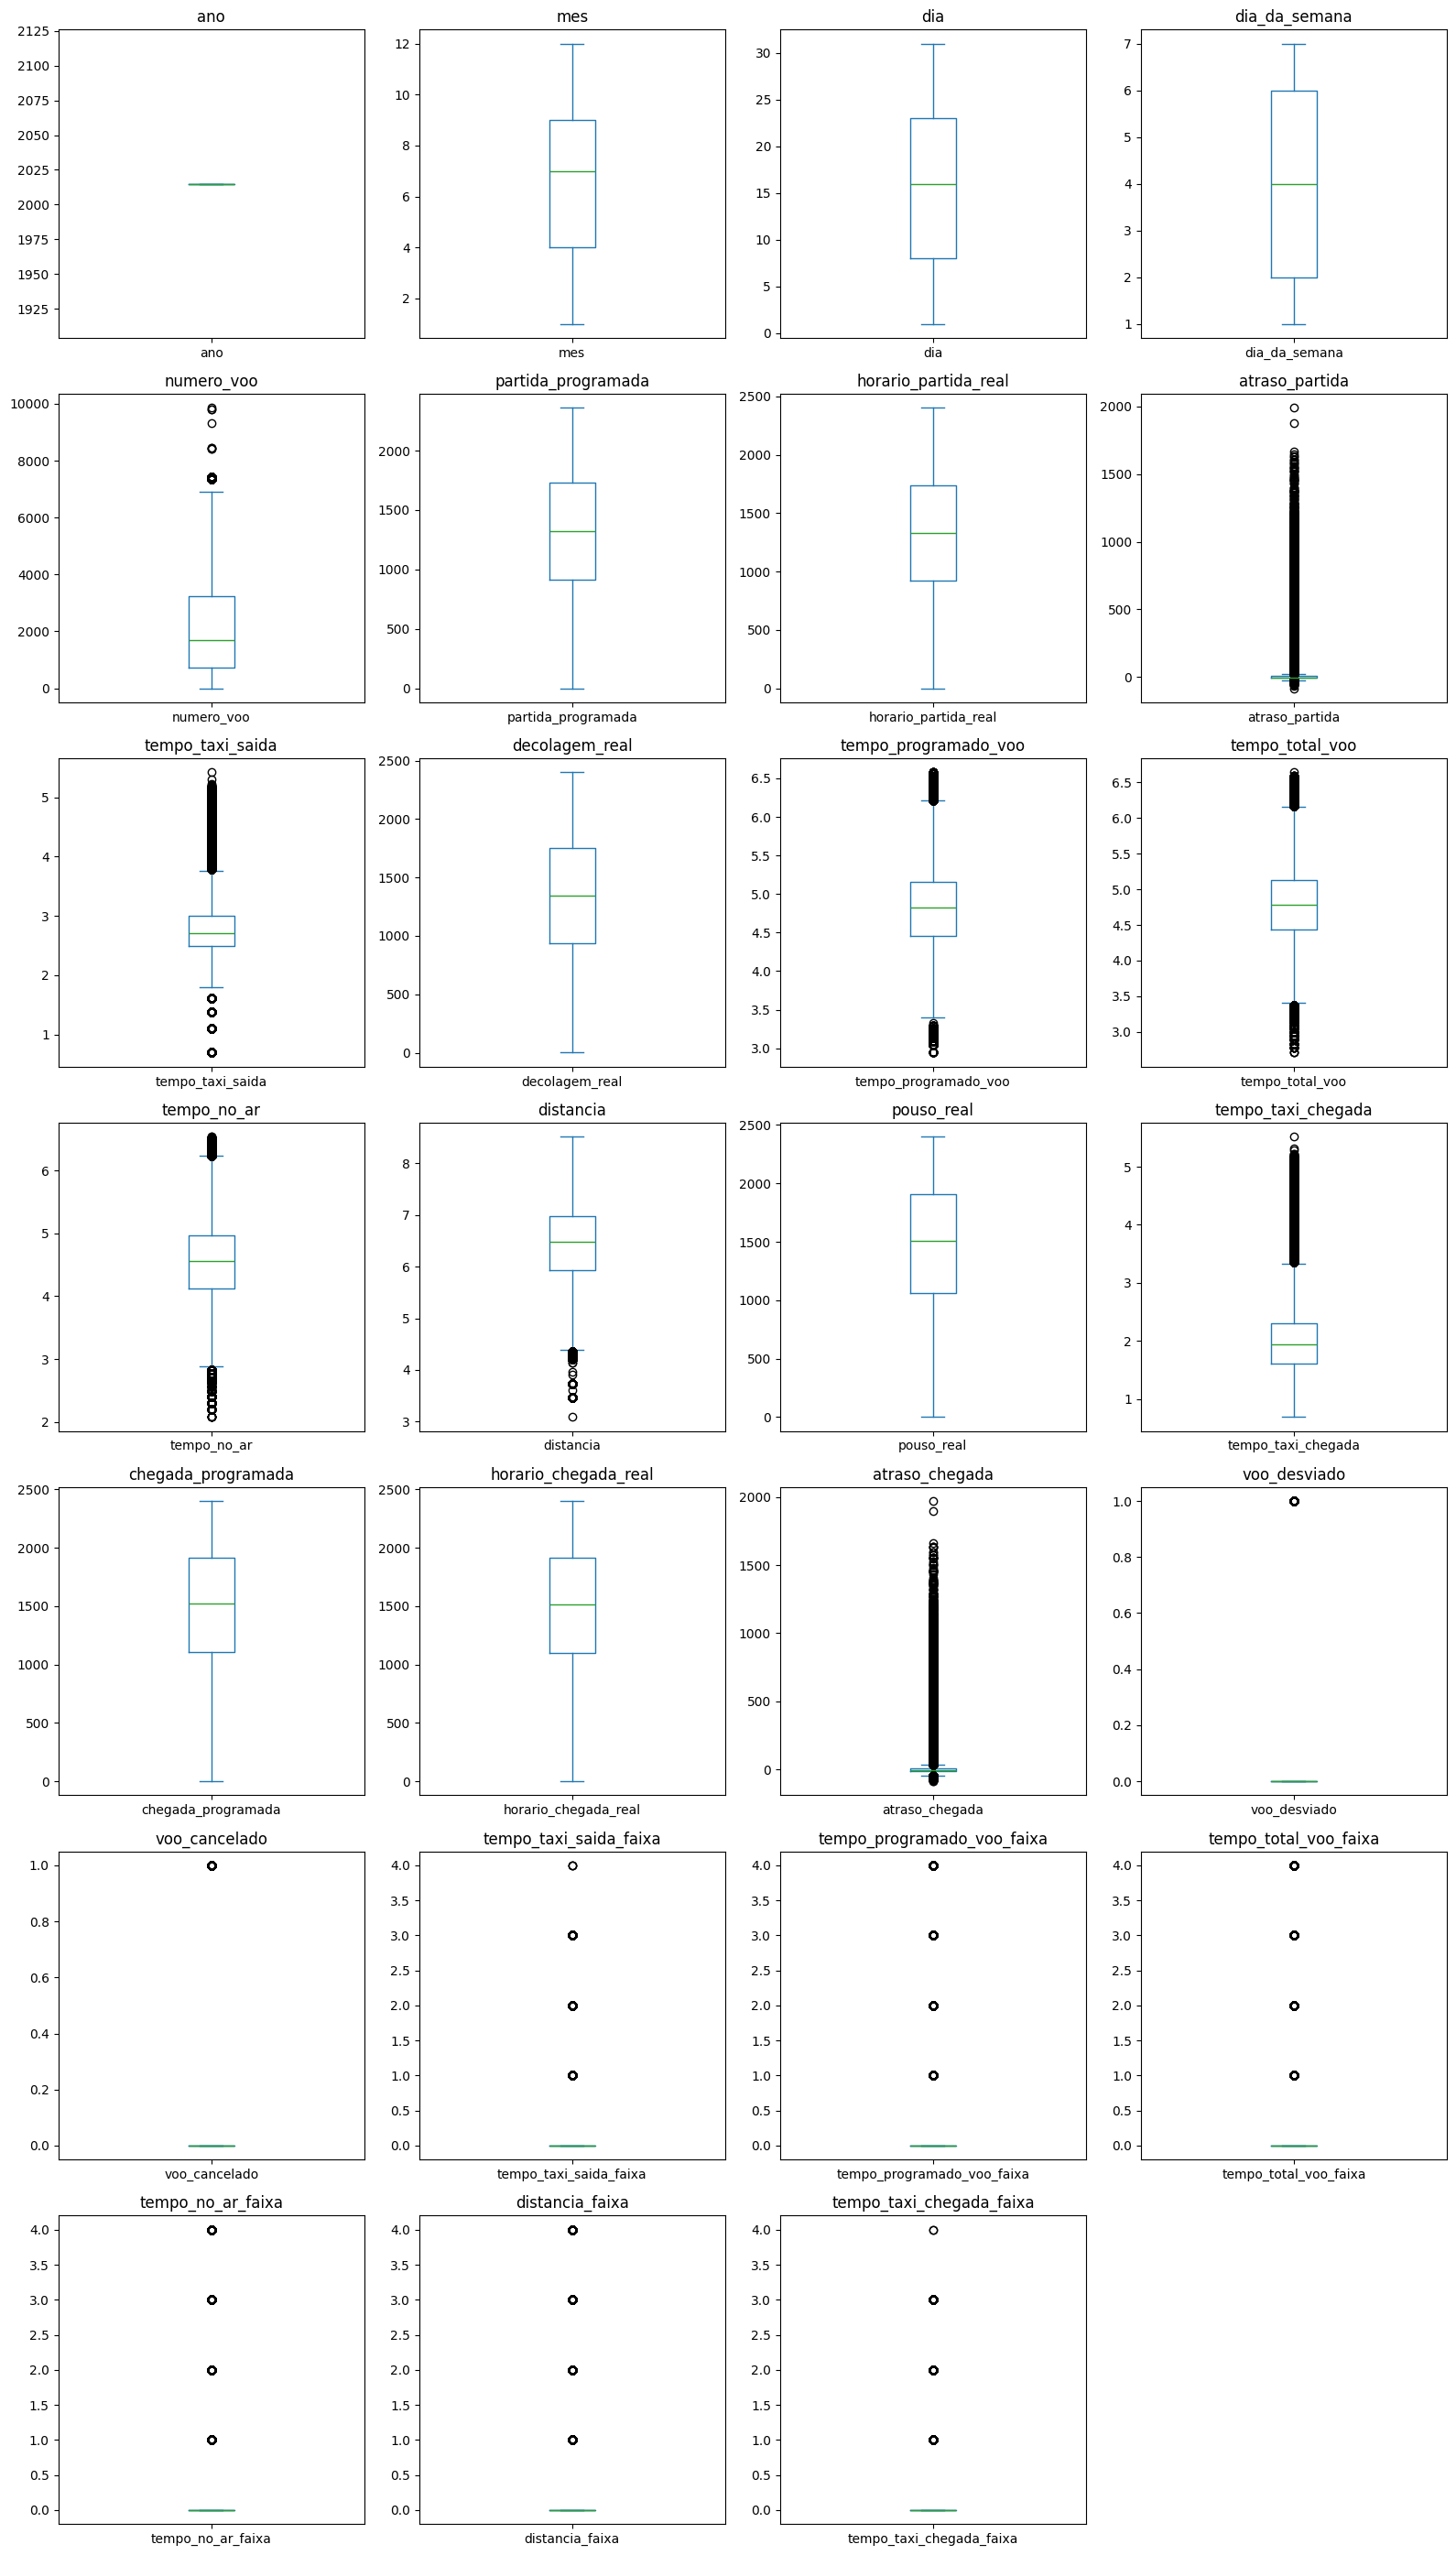

In [91]:


cols = df_flights.select_dtypes(include='number').columns

ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    df_flights[col].plot(kind='box', ax=ax)
    ax.set_title(col)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


In [92]:
df_flights.columns

Index(['ano', 'mes', 'dia', 'dia_da_semana', 'companhia_aerea', 'numero_voo',
       'matricula_aeronave', 'aeroporto_origem', 'aeroporto_destino',
       'partida_programada', 'horario_partida_real', 'atraso_partida',
       'tempo_taxi_saida', 'decolagem_real', 'tempo_programado_voo',
       'tempo_total_voo', 'tempo_no_ar', 'distancia', 'pouso_real',
       'tempo_taxi_chegada', 'chegada_programada', 'horario_chegada_real',
       'atraso_chegada', 'voo_desviado', 'voo_cancelado', 'status_voo',
       'tempo_taxi_saida_faixa', 'tempo_programado_voo_faixa',
       'tempo_total_voo_faixa', 'tempo_no_ar_faixa', 'distancia_faixa',
       'tempo_taxi_chegada_faixa'],
      dtype='object')

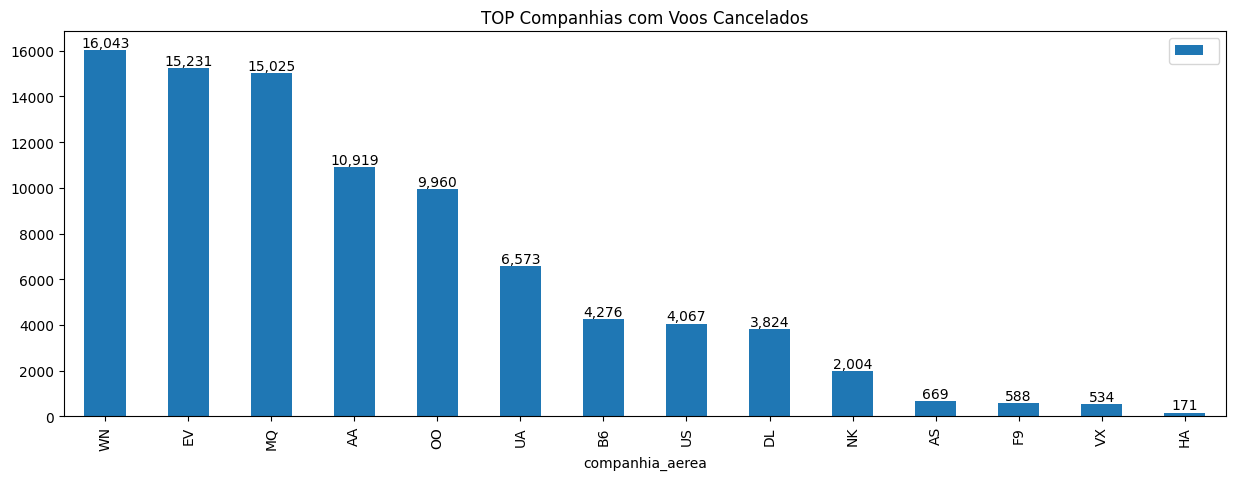

In [93]:
voos_cancelado = df_flights[df_flights['voo_cancelado'] == 1]

ax = voos_cancelado.groupby('companhia_aerea') \
                   .size() \
                   .sort_values(ascending=False) \
                   .head(25) \
                   .plot(kind='bar',
                         title='TOP Companhias com Voos Cancelados',
                         legend=True,
                         figsize=(15,5))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


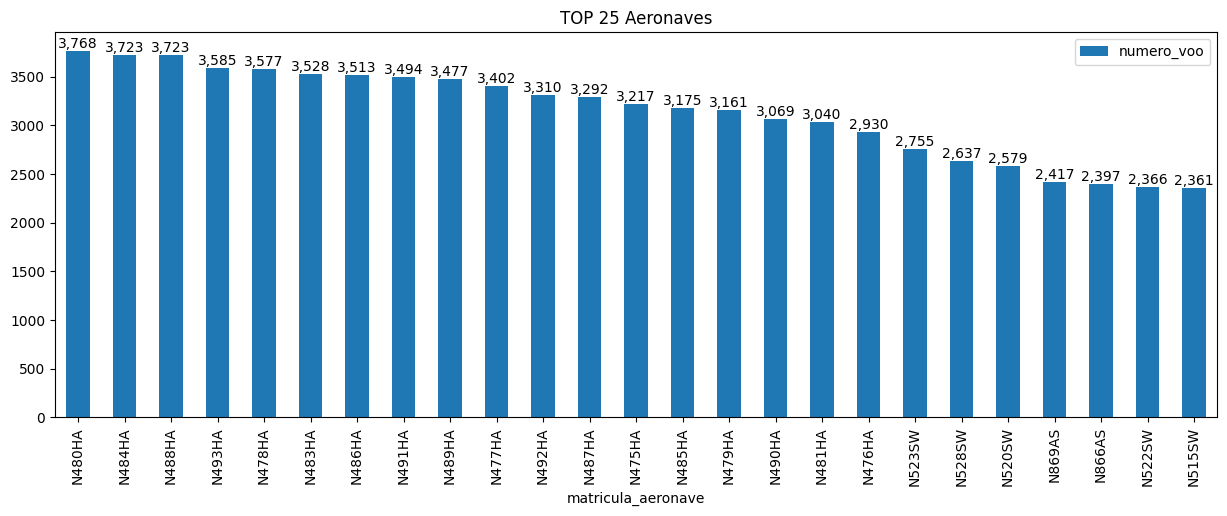

In [94]:
ax = df_flights.groupby(['matricula_aeronave'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False).head(25) \
               .plot(kind='bar',
                     title='TOP 25 Aeronaves',
                     legend=True,
                     figsize=(15,5)
                     )

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


[Text(0, 0, 'ATL'),
 Text(1, 0, 'ORD'),
 Text(2, 0, 'DFW'),
 Text(3, 0, 'DEN'),
 Text(4, 0, 'LAX'),
 Text(5, 0, 'SFO'),
 Text(6, 0, 'PHX'),
 Text(7, 0, 'IAH'),
 Text(8, 0, 'LAS'),
 Text(9, 0, 'MSP')]

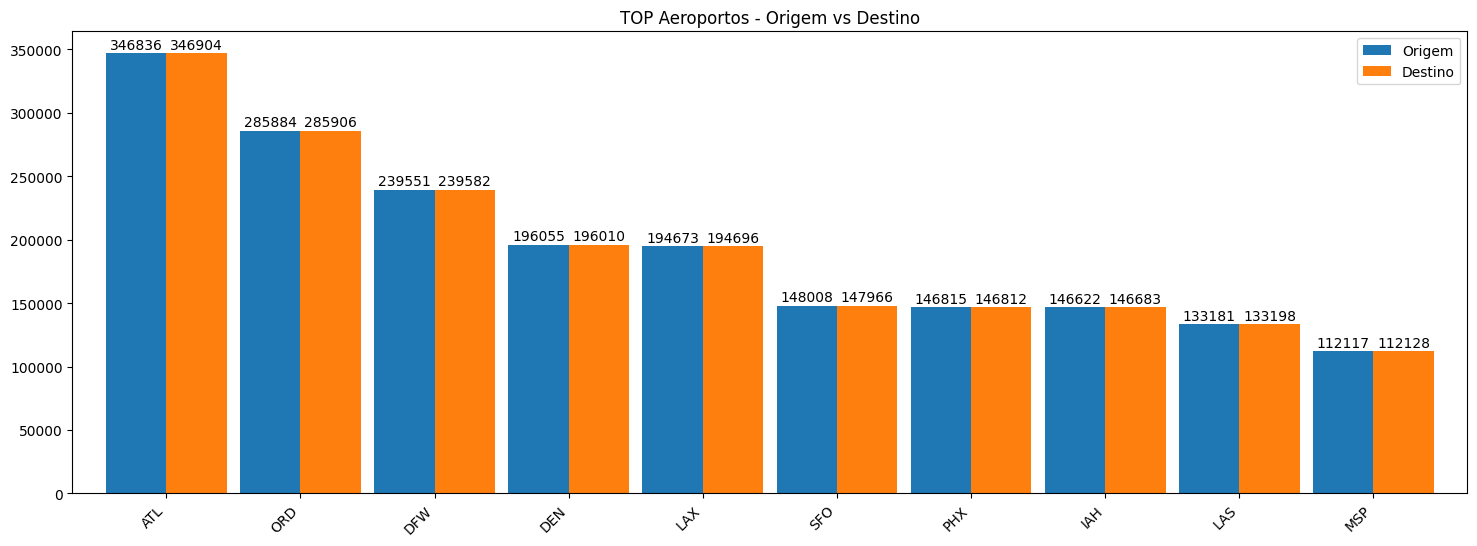

In [95]:
origem = df_flights['aeroporto_origem'].value_counts().rename('Origem')
destino = df_flights['aeroporto_destino'].value_counts().rename('Destino')

df_plot = (
    pd.concat([origem, destino], axis=1)
    .fillna(0)
    .sort_values('Destino', ascending=False)
    .head(10)
)


ax = df_plot.plot(kind='bar', figsize=(18,6), width = 0.9,
                  title='TOP Aeroportos - Origem vs Destino')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


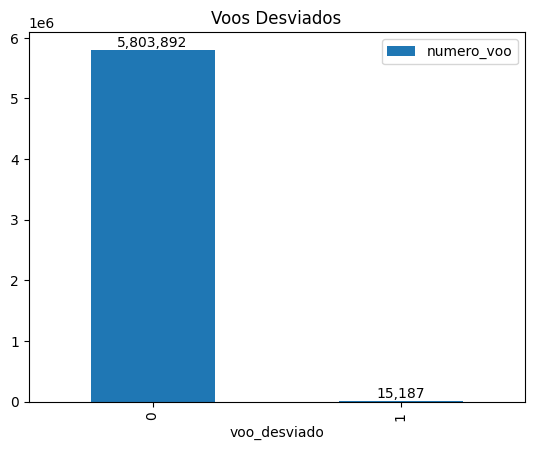

In [96]:
ax = df_flights.groupby(['voo_desviado'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False) \
               .plot(kind='bar',
                     title='Voos Desviados',
                     legend=True)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


In [97]:
df_flights.head()

,ano,mes,dia,dia_da_semana,companhia_aerea,numero_voo,matricula_aeronave,aeroporto_origem,aeroporto_destino,partida_programada,horario_partida_real,atraso_partida,tempo_taxi_saida,decolagem_real,tempo_programado_voo,tempo_total_voo,tempo_no_ar,distancia,pouso_real,tempo_taxi_chegada,chegada_programada,horario_chegada_real,atraso_chegada,voo_desviado,voo_cancelado,status_voo,tempo_taxi_saida_faixa,tempo_programado_voo_faixa,tempo_total_voo_faixa,tempo_no_ar_faixa,distancia_faixa,tempo_taxi_chegada_faixa
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,3.091042,15.0,5.327876,5.273000,5.135798,7.278629,404.0,1.609438,430,408.0,-22.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,2.564949,14.0,5.638355,5.634790,5.575949,7.754053,737.0,1.609438,750,741.0,-9.0,0,0,pontual,0.0,0.0,0.0,0.0,1.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,2.833213,34.0,5.659482,5.683580,5.587249,7.739359,800.0,2.484907,806,811.0,5.0,0,0,atrasado,0.0,0.0,0.0,0.0,1.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,2.772589,30.0,5.655992,5.641907,5.556828,7.759187,748.0,2.197225,805,756.0,-9.0,0,0,pontual,0.0,0.0,0.0,0.0,1.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,2.484907,35.0,5.463832,5.375278,5.298317,7.278629,254.0,1.791759,320,259.0,-21.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0


In [98]:
df_flights_modelo = df_flights.copy()

In [99]:
df_flights_modelo[df_flights_modelo['aeroporto_origem'] == 11433]

,ano,mes,dia,dia_da_semana,companhia_aerea,numero_voo,matricula_aeronave,aeroporto_origem,aeroporto_destino,partida_programada,horario_partida_real,atraso_partida,tempo_taxi_saida,decolagem_real,tempo_programado_voo,tempo_total_voo,tempo_no_ar,distancia,pouso_real,tempo_taxi_chegada,chegada_programada,horario_chegada_real,atraso_chegada,voo_desviado,voo_cancelado,status_voo,tempo_taxi_saida_faixa,tempo_programado_voo_faixa,tempo_total_voo_faixa,tempo_no_ar_faixa,distancia_faixa,tempo_taxi_chegada_faixa
4390917,2015,10,1,4,DL,1366,N684DA,11433,14492,1018,1014.0,-4.0,2.708050,1028.0,4.595120,4.595120,4.406719,6.218600,1149.0,1.386294,1156,1152.0,-4.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
4390927,2015,10,1,4,EV,5027,N398CA,11433,13244,1020,1045.0,25.0,2.564949,1057.0,4.770685,4.653960,4.510860,6.415097,1127.0,1.098612,1117,1129.0,12.0,0,0,atrasado,0.0,0.0,0.0,0.0,0.0,0.0
4390979,2015,10,1,4,DL,564,N891AT,11433,13930,1020,1018.0,-2.0,2.995732,1037.0,4.343805,4.276666,3.850148,5.463832,1023.0,1.945910,1036,1029.0,-7.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
4391003,2015,10,1,4,EV,5581,N921EV,11433,15412,1022,1016.0,-6.0,2.995732,1035.0,4.553877,4.595120,4.330733,6.095825,1150.0,1.609438,1156,1154.0,-2.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
4391087,2015,10,1,4,OO,4607,N659BR,11433,12884,1026,1019.0,-7.0,2.639057,1032.0,3.737670,3.688879,3.135494,4.317488,1054.0,1.609438,1107,1058.0,-9.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4848831,2015,10,30,5,DL,2793,N923DN,11433,13487,1000,959.0,-1.0,2.890372,1016.0,4.653960,4.709530,4.499810,6.270988,1045.0,1.609438,1044,1049.0,5.0,0,0,atrasado,0.0,0.0,0.0,0.0,0.0,0.0
4848832,2015,10,30,5,DL,52,N917DN,11433,13487,1000,1002.0,2.0,2.995732,1021.0,4.653960,4.727388,4.510860,6.270988,1051.0,1.386294,1044,1054.0,10.0,0,0,atrasado,0.0,0.0,0.0,0.0,0.0,0.0
4848959,2015,10,30,5,DL,379,N396DA,11433,12953,1005,1002.0,-3.0,3.178054,1025.0,4.718499,4.634729,4.317488,6.220590,1139.0,1.791759,1156,1144.0,-12.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0
4849027,2015,10,30,5,DL,1715,N904DA,11433,10397,1008,1009.0,1.0,2.890372,1026.0,4.770685,4.672829,4.418841,6.388561,1148.0,2.079442,1205,1155.0,-10.0,0,0,pontual,0.0,0.0,0.0,0.0,0.0,0.0


In [100]:
df_flights_modelo[['aeroporto_origem','aeroporto_destino']] = \
df_flights_modelo[['aeroporto_origem','aeroporto_destino']].astype('string')


In [101]:
lb = LabelEncoder()

df_flights_modelo['companhia_aerea'] = lb.fit_transform(df_flights_modelo['companhia_aerea'])
df_flights_modelo['matricula_aeronave'] = lb.fit_transform(df_flights_modelo['matricula_aeronave'])
df_flights_modelo['aeroporto_origem'] = lb.fit_transform(df_flights_modelo['aeroporto_origem'])
df_flights_modelo['aeroporto_destino'] = lb.fit_transform(df_flights_modelo['aeroporto_destino'])

In [102]:

(df_flights_modelo.isna().sum() / df_flights_modelo.shape[0] * 100).sort_values(ascending = False)

tempo_total_voo_faixa         0.000739
tempo_programado_voo_faixa    0.000361
tempo_no_ar_faixa             0.000137
tempo_taxi_saida_faixa        0.000017
ano                           0.000000
mes                           0.000000
dia                           0.000000
dia_da_semana                 0.000000
aeroporto_destino             0.000000
partida_programada            0.000000
horario_partida_real          0.000000
atraso_partida                0.000000
companhia_aerea               0.000000
numero_voo                    0.000000
matricula_aeronave            0.000000
aeroporto_origem              0.000000
tempo_total_voo               0.000000
tempo_programado_voo          0.000000
decolagem_real                0.000000
tempo_taxi_saida              0.000000
tempo_no_ar                   0.000000
distancia                     0.000000
pouso_real                    0.000000
tempo_taxi_chegada            0.000000
voo_desviado                  0.000000
atraso_chegada           

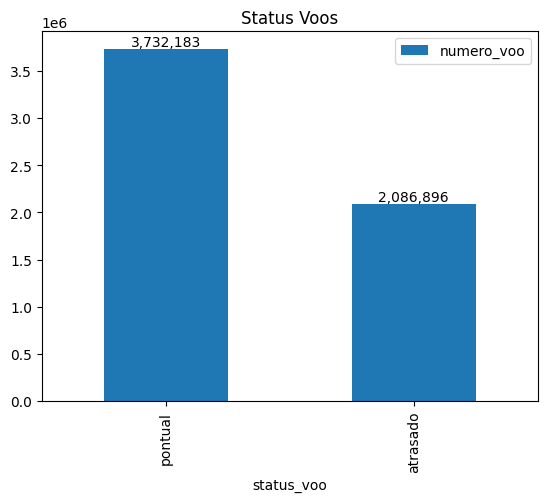

In [103]:
ax = df_flights_modelo.groupby(['status_voo'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False) \
               .plot(kind='bar',
                     title='Status Voos',
                     legend=True)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


In [150]:
predict = df_flights_modelo.drop(columns=[
    'atraso_chegada',
    'tempo_taxi_chegada',
    'horario_chegada_real',
    'tempo_total_voo',
    'voo_cancelado',
    'tempo_no_ar',
    'status_voo',
    'pouso_real',
    'numero_voo',

    'tempo_total_voo_faixa',
    'tempo_no_ar_faixa',
    'tempo_taxi_chegada_faixa'
    

   
])

target = df_flights_modelo.iloc[:, 25]
target = target.map({'pontual': 0, 'atrasado': 1})



In [151]:
predict.columns

Index(['ano', 'mes', 'dia', 'dia_da_semana', 'companhia_aerea',
       'matricula_aeronave', 'aeroporto_origem', 'aeroporto_destino',
       'partida_programada', 'horario_partida_real', 'atraso_partida',
       'tempo_taxi_saida', 'decolagem_real', 'tempo_programado_voo',
       'distancia', 'chegada_programada', 'voo_desviado',
       'tempo_taxi_saida_faixa', 'tempo_programado_voo_faixa',
       'distancia_faixa'],
      dtype='object')

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    predict,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target   
)

In [153]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',      
    n_jobs=-1,
    random_state=42,
    eval_metric='logloss'
)


In [154]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
#y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [203]:


thresholds = np.arange(0.05, 0.96, 0.05)

resultados = []

for t in thresholds:
    
    
    y_pred_t = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    resultados.append([t, precision, recall, f1])


df_thr = pd.DataFrame(resultados, columns=[
    'threshold', 'precision', 'recall', 'f1'
])


df_thr = df_thr.sort_values('f1', ascending=False)

print(df_thr.head(10))

best_threshold = df_thr.iloc[0]['threshold']
print("Melhor threshold:", best_threshold)


    threshold  precision    recall        f1
7        0.40   0.849662  0.783513  0.815248
8        0.45   0.875515  0.759859  0.813597
6        0.35   0.818708  0.807817  0.813226
9        0.50   0.897483  0.737414  0.809612
5        0.30   0.782323  0.834064  0.807365
10       0.55   0.916493  0.714806  0.803182
4        0.25   0.738011  0.861656  0.795055
11       0.60   0.933134  0.691949  0.794644
12       0.65   0.947536  0.669027  0.784290
3        0.20   0.684401  0.891770  0.774444
Melhor threshold: 0.4


In [204]:
y_pred = (y_prob >= best_threshold).astype(int)

In [190]:
print(best_threshold)
print((y_prob >= best_threshold).sum())


0.4
384885


In [158]:
for col, imp in zip(predict.columns, model.feature_importances_):
    print(col, imp)

ano 0.0
mes 0.0072020097
dia 0.0035953685
dia_da_semana 0.0024549074
companhia_aerea 0.021513835
matricula_aeronave 0.004294358
aeroporto_origem 0.012333895
aeroporto_destino 0.0072943484
partida_programada 0.022403477
horario_partida_real 0.02295567
atraso_partida 0.51660436
tempo_taxi_saida 0.102121994
decolagem_real 0.016615648
tempo_programado_voo 0.019030275
distancia 0.0144654745
chegada_programada 0.0057641673
voo_desviado 0.037955403
tempo_taxi_saida_faixa 0.171157
tempo_programado_voo_faixa 0.008139946
distancia_faixa 0.0040979264


In [205]:
print(classification_report(y_test, y_pred)) 
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90    746437
           1       0.85      0.78      0.82    417379

    accuracy                           0.87   1163816
   macro avg       0.87      0.85      0.86   1163816
weighted avg       0.87      0.87      0.87   1163816

ROC AUC: 0.9296809884500322


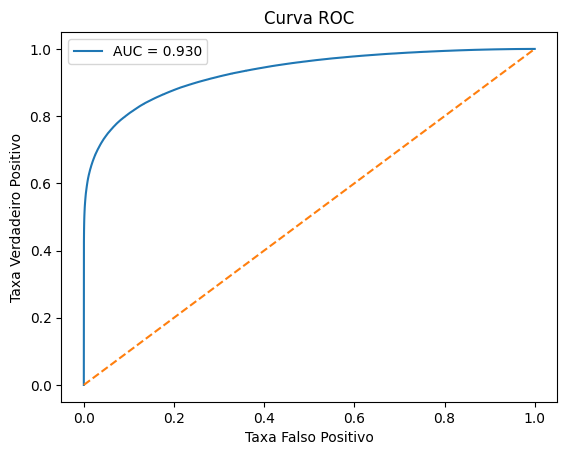

In [211]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Taxa Falso Positivo")
plt.ylabel("Taxa Verdadeiro Positivo")
plt.title("Curva ROC")
plt.legend()
plt.show()

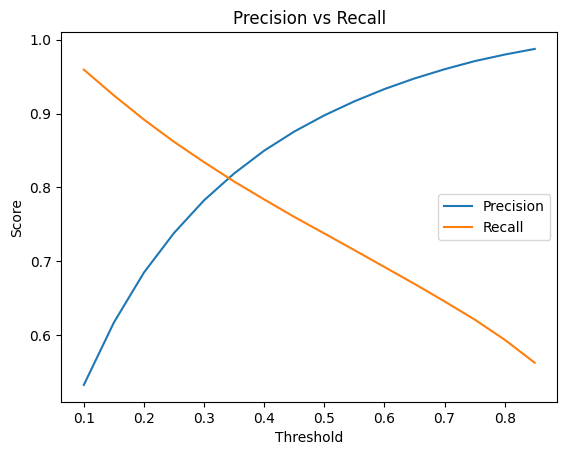

In [210]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.05)

precisions = []
recalls = []

for t in thresholds:
    y_pred_ = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_))
    recalls.append(recall_score(y_test, y_pred_))

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.show()

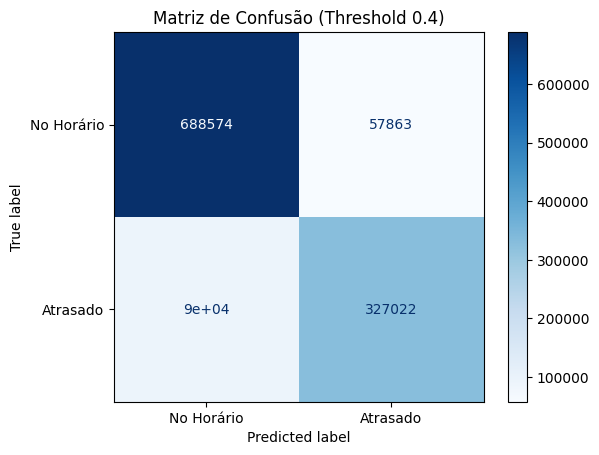

Acertos no Horário (TN): 688574
Alarmes Falsos (FP): 57863
Atrasos não detectados (FN): 90357
Atrasos detectados corretamente (TP): 327022


In [192]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Horário', 'Atrasado'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusão (Threshold {best_threshold})')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Acertos no Horário (TN): {tn}")
print(f"Alarmes Falsos (FP): {fp}")
print(f"Atrasos não detectados (FN): {fn}")
print(f"Atrasos detectados corretamente (TP): {tp}")

In [208]:
atrasos_perdidos = y_test[(y_pred == 0) & (y_test == 1)]
minutos_perdidos = df_flights.loc[atrasos_perdidos.index, 'atraso_chegada'].mean()
print(f"Média de minutos de atraso dos voos que o modelo não previu: {minutos_perdidos:.2f} min")

Média de minutos de atraso dos voos que o modelo não previu: 7.52 min
